<a href="https://colab.research.google.com/github/keandres12/MineriaDeDatos/blob/Entrega3/Entrega3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MINERÍA DE DATOS — EVALUACIÓN 3
## Análisis Exploratorio y Modelación Predictiva: Mercado Chileno vs Crudo Internacional

* **Integrante:** Kevin Castro
* **Asignatura:** Minería de Datos

### 1. Justificación del Dataset y Contexto Económico
Este proyecto analiza la relación histórica entre los dos marcadores de petróleo crudo más importantes del mundo, **Brent Crude** y **WTI**, frente al precio minorista del combustible en Chile.


# 1. Importación de Librerías


In [25]:
# ====================================================================
# FASE 1: IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ====================================================================
!pip install yfinance -q

import os
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuración global de visualización de números
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Conectar Google Drive de forma segura
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## FASE 2: CARGA Y PREPROCESAMIENTO DE DATOS (DATA CLEANING)
En esta fase cargamos el dataset unificado gigante, resolvemos los valores nulos mediante técnicas avanzadas de series de tiempo y aplicamos filtros de seguridad para eliminar anomalías de digitación.


# 2. Carga y Estructuración de Datos


In [2]:
# 2. Definir la ruta exacta de tu archivo ya consolidado
ruta_archivo = '/content/drive/MyDrive/dataset/dataset_final_unido.csv'

print("Cargando el super-dataset... (esto puede tomar un minuto o dos)")

# 3. Leer el archivo CSV
# Usamos low_memory=False porque al ser un archivo gigante, ayuda a que Pandas
# no se confunda con los tipos de datos de cada columna.
df = pd.read_csv(ruta_archivo, low_memory=False)

# 4. Ver el tamaño y las primeras filas para confirmar
print(f"\n¡Dataset cargado exitosamente! Total de filas: {len(df)}")

# df.info() te mostrará el tipo de dato de cada columna y cuántos nulos hay
df.info()

# Mostrar las primeras 5 filas
df.head()

Cargando el super-dataset... (esto puede tomar un minuto o dos)

¡Dataset cargado exitosamente! Total de filas: 8925675
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8925675 entries, 0 to 8925674
Data columns (total 19 columns):
 #   Column               Dtype  
---  ------               -----  
 0   id                   object 
 1   razon_social         object 
 2   distribuidor         object 
 3   direccion_calle      object 
 4   direccion_numero     float64
 5   comuna               object 
 6   region               object 
 7   precio               float64
 8   fecha_actualizacion  object 
 9   combustible          object 
 10  latitud              object 
 11  longitud             object 
 12  unidad_cobro         object 
 13  atencion             object 
 14  hora_actualizacion   object 
 15  es_electrolinera     float64
 16  es_gasolinera        float64
 17  Precio_Brent_USD     float64
 18  Precio_WTI_USD       float64
dtypes: float64(6), object(13)
memory usage: 1.3+ GB


,id,razon_social,distribuidor,direccion_calle,direccion_numero,comuna,region,precio,fecha_actualizacion,combustible,latitud,longitud,unidad_cobro,atencion,hora_actualizacion,es_electrolinera,es_gasolinera,Precio_Brent_USD,Precio_WTI_USD
0,co1312002,Sociedad Herrera Bravo Ltda,COPEC,Avenida Irarrázaval,5277.00,Ñuñoa,Metropolitana,759.00,2012-01-01,Gasolina 93,"-33,4540062109273","-70,57525992393493",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pb630302,Distribuidora Dagnino Giacobbe y Cía. Ltda. 7...,Sin Bandera,Camino a Codegua Km,1.00,Chimbarongo,Gral. Bernardo O'Higgins,612.00,2012-12-13,Petroleo Diesel,"-34,71739081954427","-71,02941691875458",NaN,NaN,NaN,NaN,NaN,107.91,85.89
2,co120501,SOCIEDAD COMERCIAL IBAï¿½EZ Y NEGRON LTDA.,COPEC,"PANAMERICANA NORTE KM 1750, EX S. V",0.00,Pozo Almonte,Tarapacá,777.00,2012-12-06,Gasolina 95,"-21,09225805724834","-69,5928230881691",NaN,NaN,NaN,NaN,NaN,107.03,86.26
3,te1312301,Gilberto Zamorano Vega,SHELL,Holanda,2808.00,Providencia,Metropolitana,790.00,2012-12-06,Gasolina 97,"-33,44420837761395","-70,59720039367676",NaN,NaN,NaN,NaN,NaN,107.03,86.26
4,co1313201,PATRICIO REYES INFANTE Y CIA LTDA,COPEC,Av. Vitacura,6380.00,Vitacura,Metropolitana,873.00,2012-09-06,Gasolina 97,"-33,38974288164123","-70,57051241397858",NaN,NaN,NaN,NaN,NaN,113.49,95.53


# Fase de Limpieza y Preprocesamiento

In [3]:
# 1. TRATAR COLUMNAS INFORMATIVAS (Rellenar en lugar de borrar)
columnas_texto = ['unidad_cobro', 'atencion', 'hora_actualizacion']
df[columnas_texto] = df[columnas_texto].fillna('No Informado')

columnas_bandera = ['es_electrolinera', 'es_gasolinera']
df[columnas_bandera] = df[columnas_bandera].fillna(0)

# Reemplazar nulos en la columna 'razon_social' por 'no informa'
df['razon_social'] = df['razon_social'].fillna('no informa')

# 2. ORDENAR Y APLICAR FFILL (Precios Locales e Internacionales)
df = df.sort_values(by=['id', 'combustible', 'fecha_actualizacion'])
print("Rellenando precios locales por estación... (FFill agrupado)")
df['precio'] = df.groupby(['id', 'combustible'])['precio'].ffill()

df = df.sort_values(by='fecha_actualizacion')
columnas_petroleo = ['Precio_Brent_USD', 'Precio_WTI_USD']
df[columnas_petroleo] = df[columnas_petroleo].ffill()

# 3. ELIMINAR FILAS SIN HISTORIAL INICIAL
columnas_cruciales = ['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']
df_limpio = df.dropna(subset=columnas_cruciales)

# 4. ELIMINAR COLUMNAS QUE NO APORTAN AL MODELO PREDICTIVO
columnas_a_eliminar = ['id', 'latitud', 'direccion_numero', 'direccion_calle',
                       'longitud', 'unidad_cobro', 'atencion', 'hora_actualizacion',
                       'es_electrolinera', 'es_gasolinera']
df_limpio = df_limpio.drop(columns=columnas_a_eliminar)

# 5. FILTROS DE SEGURIDAD (Rango lógico de precios en Chile)
df_limpio = df_limpio[(df_limpio['precio'] >= 630) & (df_limpio['precio'] <= 1650)]

# 6. ORDENAR CRONOLÓGICAMENTE FINAL Y REINICIAR ÍNDICE
df_limpio = df_limpio.sort_values(by='fecha_actualizacion', ascending=True).reset_index(drop=True)

print(f"\n¡Proceso de limpieza completado!")
print(f"Filas originales: {len(df)} | Filas resultantes: {len(df_limpio)}")
print(f"Nulos remanentes:\n{df_limpio.isnull().sum()}")

Rellenando precios locales por estación... (FFill agrupado)

¡Proceso de limpieza completado!
Filas originales: 8925675 | Filas resultantes: 7341046
Nulos remanentes:
razon_social           0
distribuidor           0
comuna                 0
region                 0
precio                 0
fecha_actualizacion    0
combustible            0
Precio_Brent_USD       0
Precio_WTI_USD         0
dtype: int64


# Visualizamos las primeras 5 filas

In [4]:
df_limpio.head()

,razon_social,distribuidor,comuna,region,precio,fecha_actualizacion,combustible,Precio_Brent_USD,Precio_WTI_USD
0,MARCELA BUSTAMANTE AGUILAR Rut 7.333.127-7,SHELL,San Miguel,Metropolitana,765.00,2012-01-03,Gasolina 95,112.13,102.96
1,MARIO DANIEL CONTRERAS ESPINOZA ESTACIONES DE ...,SHELL,Quinta Normal,Metropolitana,759.00,2012-01-03,Gasolina 95,112.13,102.96
2,Lobos arqueros S.P.A,SHELL,Santiago Centro,Metropolitana de Santiago,738.00,2012-01-03,93,112.13,102.96
3,Inversiones Los Lagos SpA.,SHELL,Cerro Navia,Metropolitana de Santiago,757.00,2012-01-03,95,112.13,102.96
4,Distribuidora de Combustibles Luis Troncoso Pe...,SHELL,La Pintana,Metropolitana de Santiago,786.00,2012-01-03,97,112.13,102.96


# Visualizamos las ultimas 5 filas

In [5]:
df_limpio.tail()

,razon_social,distribuidor,comuna,region,precio,fecha_actualizacion,combustible,Precio_Brent_USD,Precio_WTI_USD
7341041,"VENTA DE COMBUSTIBLE,LUBRICANTES Y MINIMARKET ...",SHELL,Romeral,Del Maule,1522.00,2026-06-22,93,77.90,74.82
7341042,Sociedad Comercial FariÃ±a Spa,SHELL,Concón,Valparaíso,1492.00,2026-06-22,93,77.90,74.82
7341043,Sociedad Comercial FariÃ±a Spa,SHELL,Concón,Valparaíso,1502.00,2026-06-22,93,77.90,74.82
7341044,Garcia y Cia. Ltda.,SHELL,San Bernardo,Metropolitana de Santiago,1497.00,2026-06-22,A93,77.90,74.82
7341045,Inversiones y Estudios Las Vertientes Ltda.,SHELL,Cerrillos,Metropolitana de Santiago,1442.00,2026-06-22,93,77.90,74.82


# Devuelve la cantidad de filas y columnas respectivamente

In [6]:
df_limpio.shape

(7341046, 9)

# Observamos la columna y sus tipos de datos

In [7]:
df_limpio.dtypes

,0
razon_social,object
distribuidor,object
comuna,object
region,object
precio,float64
fecha_actualizacion,object
combustible,object
Precio_Brent_USD,float64
Precio_WTI_USD,float64


# Mostramos los nombres de las columnas

In [8]:
df_limpio.columns

Index(['razon_social', 'distribuidor', 'comuna', 'region', 'precio',
       'fecha_actualizacion', 'combustible', 'Precio_Brent_USD',
       'Precio_WTI_USD'],
      dtype='object')

In [9]:
df_limpio[['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']].describe()

,precio,Precio_Brent_USD,Precio_WTI_USD
count,7341046.00,7341046.00,7341046.00
mean,901.21,75.71,69.95
std,210.12,23.33,21.38
min,630.00,19.33,-37.63
25%,760.00,58.35,52.61
50%,833.00,72.88,68.19
75%,981.00,94.67,88.07
max,1650.00,127.98,123.70


# Análisis Exploratorio de Datos

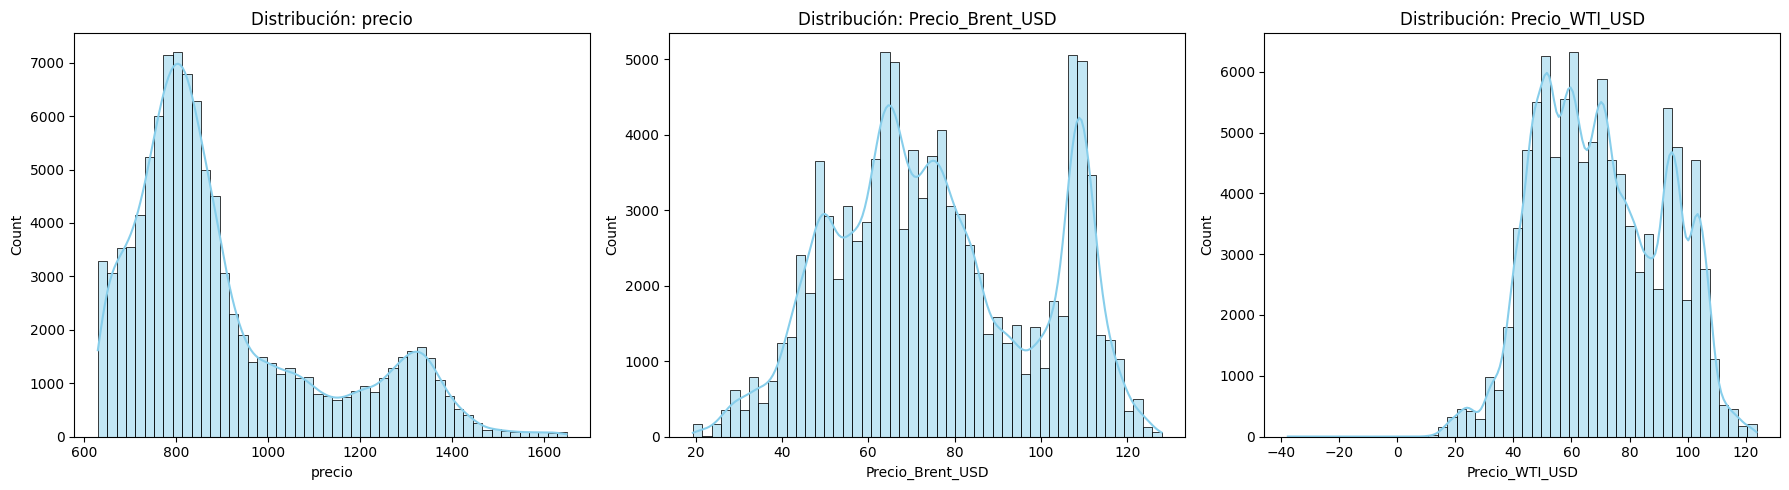

In [10]:
cols_numericas = ['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']
plt.figure(figsize=(18, 5))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_limpio[col].sample(100000, random_state=42), kde=True, bins=50, color='skyblue')
    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

# Grafico

In [11]:
cols_numericas = [
    'precio','Precio_Brent_USD','Precio_WTI_USD'
]

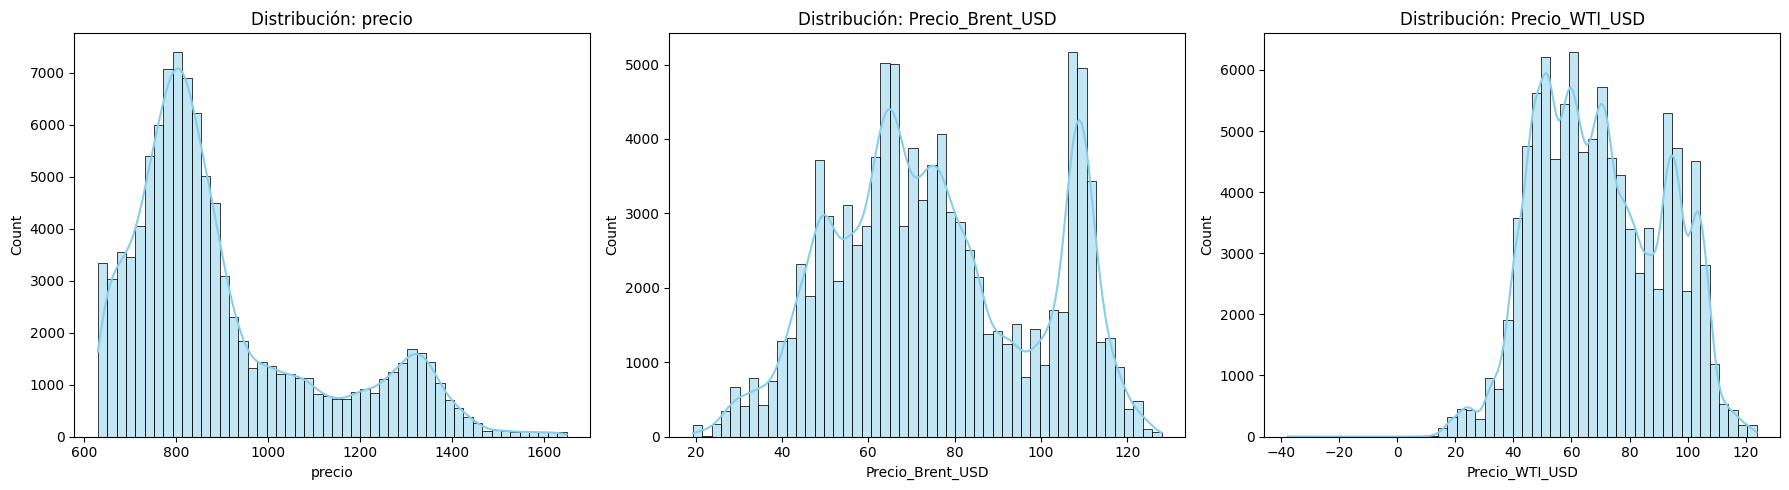

In [12]:
# Cambiamos el tamaño para que sea 1 fila y 3 columnas (horizontal)
plt.figure(figsize=(18, 5))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 3, i)

    # Usamos .sample(100000) para que dibuje el gráfico rápido sin que Colab explote.
    # El parámetro bins=50 agrupa las barras para que se vea más limpio.
    sns.histplot(df_limpio[col].sample(100000), kde=True, bins=50, color='skyblue')

    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

###Matriz de Correlación

Para comprender la fuerza y la dirección de las relaciones lineales entre nuestras variables macroeconómicas continuas, calculamos la **Matriz de Correlación de Pearson**.

Este mapa de calor nos permite evaluar dos aspectos críticos:
1. **La correlación predictiva:** Qué tan fuerte es la relación directa entre los marcadores internacionales (Brent/WTI) y el precio en Chile.
2. **La multicolinealidad:** El nivel de redundancia entre los propios marcadores internacionales.

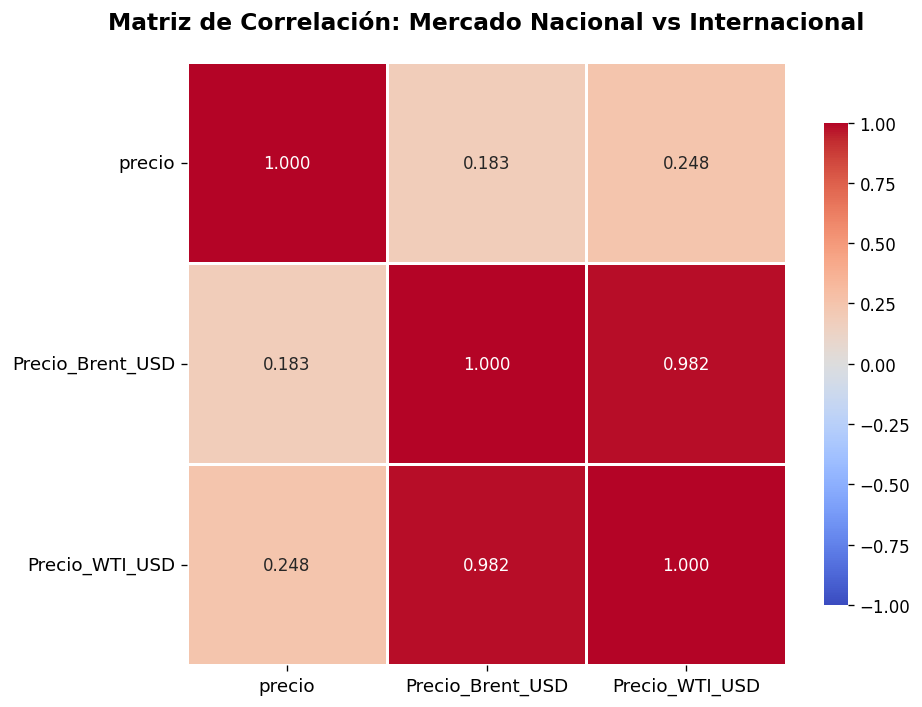

In [13]:
# *** LÍNEA SALVADORA *** # Aseguramos la existencia de df_macro agrupando nuevamente los datos limpios
df_macro = df_limpio.groupby(['fecha_actualizacion', 'combustible']).agg({
    'precio': 'mean',
    'Precio_Brent_USD': 'mean',
    'Precio_WTI_USD': 'mean'
}).reset_index()

# 1. Seleccionar únicamente las variables numéricas continuas del dataset macro
columnas_numericas = ['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']
df_correlacion = df_macro[columnas_numericas]

# 2. Calcular la matriz de correlación de Pearson
matriz_corr = df_correlacion.corr()

# 3. Configurar el lienzo
plt.figure(figsize=(8, 6), dpi=120)

# 4. Generar el Mapa de Calor (Heatmap)
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    linewidths=1.5,
    cbar_kws={"shrink": 0.8}
)

# 5. Configurar textos y títulos
plt.title('Matriz de Correlación: Mercado Nacional vs Internacional',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

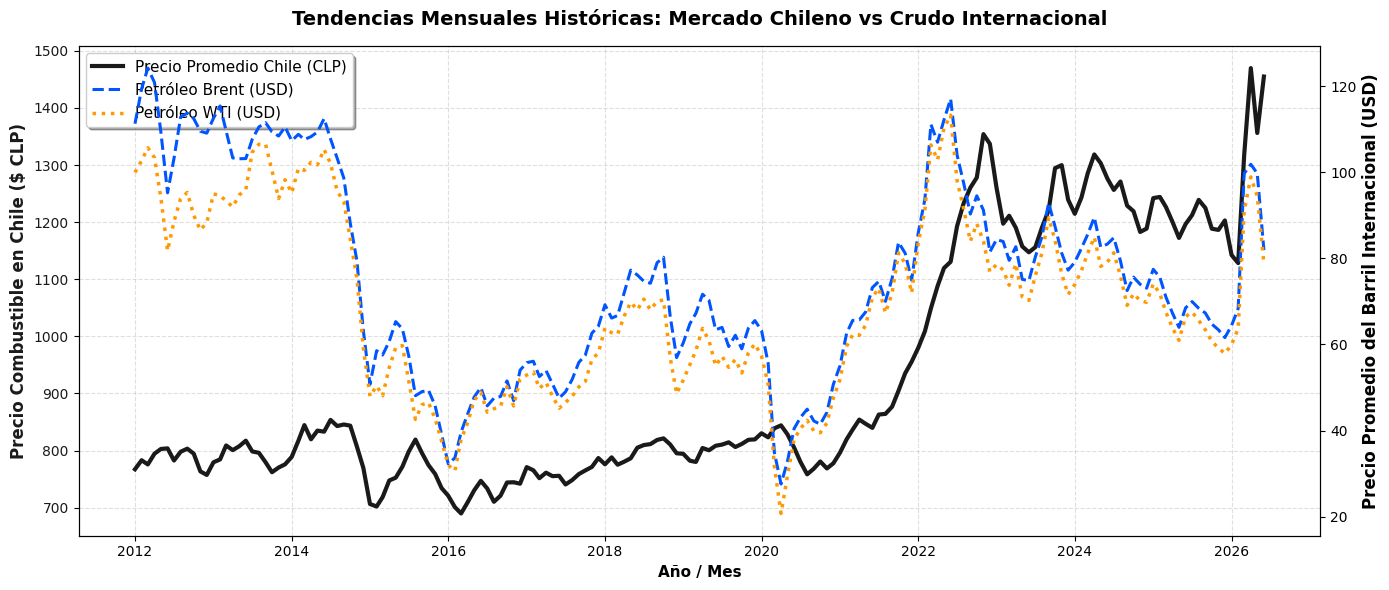

In [14]:
# 1. Asegurar formato de fecha
df_limpio['fecha_actualizacion'] = pd.to_datetime(df_limpio['fecha_actualizacion'])

# 2. Agrupar por MES usando resample (calcula el promedio mensual de los precios)
df_mensual_plot = df_limpio.set_index('fecha_actualizacion').resample('MS').agg({
    'precio': 'mean',
    'Precio_Brent_USD': 'mean',
    'Precio_WTI_USD': 'mean'
}).sort_index()

# 3. Configuración del lienzo
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- PALETA DE COLORES DE ALTO CONTRASTE ---
color_chile = '#1A1A1A'  # Negro Carbón (Para el mercado local)
color_brent = '#0055FF'  # Azul Eléctrico
color_wti = '#FF9900'    # Naranja Neón / Ámbar

# --- EJE IZQUIERDO: Precio Mensual Promedio en Chile (CLP) ---
ax1.plot(df_mensual_plot.index, df_mensual_plot['precio'],
         color=color_chile, linestyle='-', linewidth=3.0, label='Precio Promedio Chile (CLP)')

ax1.set_xlabel('Año / Mes', fontsize=11, fontweight='bold')
ax1.set_ylabel('Precio Combustible en Chile ($ CLP)', color=color_chile, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_chile)
ax1.grid(True, linestyle='--', alpha=0.4)

# --- EJE DERECHO: Precios Mensuales Internacionales (USD) ---
ax2 = ax1.twinx()

# Brent: Línea segmentada
ax2.plot(df_mensual_plot.index, df_mensual_plot['Precio_Brent_USD'],
         color=color_brent, linestyle='--', linewidth=2.2, label='Petróleo Brent (USD)')

# WTI: Línea de puntos
ax2.plot(df_mensual_plot.index, df_mensual_plot['Precio_WTI_USD'],
         color=color_wti, linestyle=':', linewidth=2.5, label='Petróleo WTI (USD)')

ax2.set_ylabel('Precio Promedio del Barril Internacional (USD)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')

# 4. UNIFICAR LEYENDAS
lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()
ax1.legend(lineas_1 + lineas_2, etiquetas_1 + etiquetas_2,
           loc='upper left', fontsize=11, facecolor='white', frameon=True, shadow=True)

plt.title('Tendencias Mensuales Históricas: Mercado Chileno vs Crudo Internacional', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

   REPORTE DE ALZAS Y CAÍDAS MENSUALES (MoM)

--- Mercado Local: Combustible Chile (CLP) ---
Mayor ALZA en un solo mes:    +16.74%  (Ocurrió en: 2026-03)
Mayor CAÍDA en un solo mes:   -8.22%
Promedio de variación mensual: 0.41%

--- Mercado Internacional: Brent (USD) ---
Mayor ALZA en un solo mes:    +45.93%  (Ocurrió en: 2026-03)
Mayor CAÍDA en un solo mes:   -37.31%
Promedio de variación mensual: 0.23%

--- Mercado Internacional: WTI (USD) ---
Mayor ALZA en un solo mes:    +43.00%  (Ocurrió en: 2026-03)
Mayor CAÍDA en un solo mes:   -37.65%
Promedio de variación mensual: 0.36%



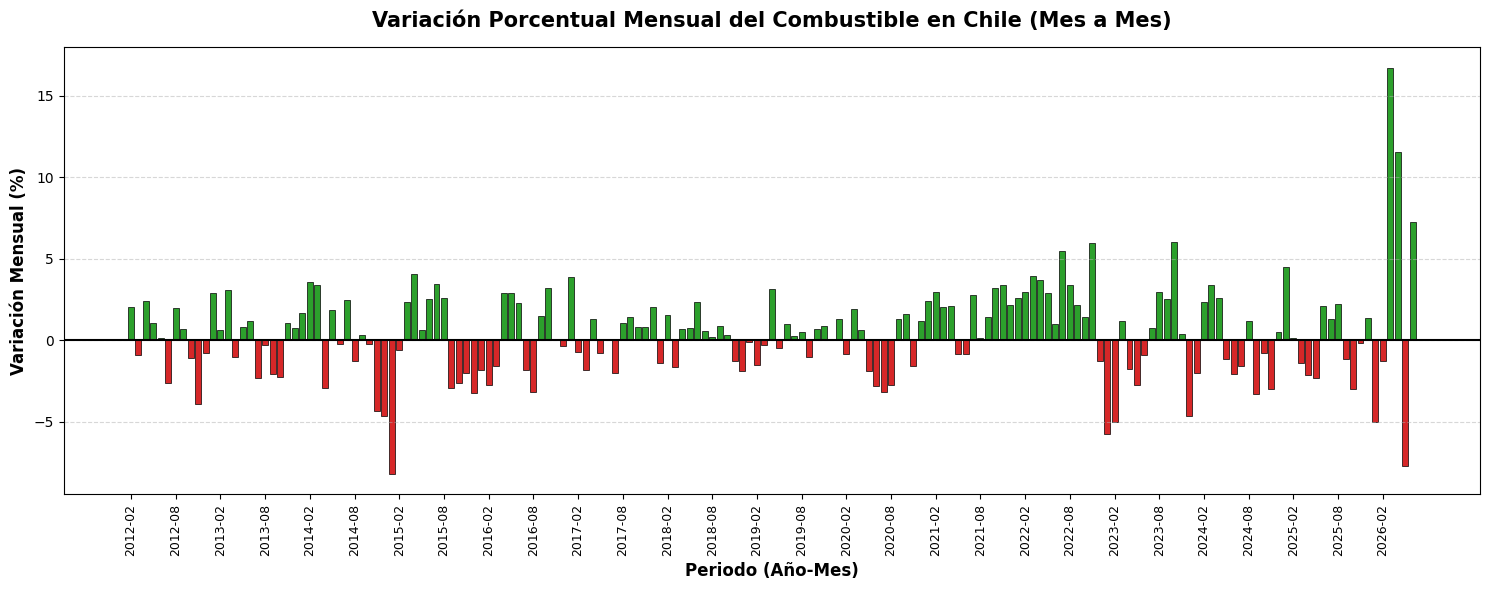

In [15]:
# 1. Preparar el dataset: Asegurar fecha y ponerla como índice
df_mes = df_limpio.copy()
df_mes['fecha_actualizacion'] = pd.to_datetime(df_mes['fecha_actualizacion'])
df_mes = df_mes.set_index('fecha_actualizacion')

# 2. Agrupar por MES ('ME' = Month End) calculando el promedio
df_mensual = df_mes[['precio', 'Precio_Brent_USD', 'Precio_WTI_USD']].resample('ME').mean()

# 3. Calcular la variación porcentual mensual (* 100)
# Eliminar la primera fila (NaN) porque no tiene un mes previo con el cual compararse
df_var_mensual = df_mensual.pct_change().dropna() * 100

print("==========================================================")
print("   REPORTE DE ALZAS Y CAÍDAS MENSUALES (MoM)")
print("==========================================================\n")

columnas_analisis = {
    'precio': 'Mercado Local: Combustible Chile (CLP)',
    'Precio_Brent_USD': 'Mercado Internacional: Brent (USD)',
    'Precio_WTI_USD': 'Mercado Internacional: WTI (USD)'
}

for col, nombre in columnas_analisis.items():
    alza_max = df_var_mensual[col].max()
    caida_max = df_var_mensual[col].min()
    promedio_mensual = df_var_mensual[col].mean()

    # Encontrar exactamente en qué mes ocurrió la mayor alza
    mes_peor_alza = df_var_mensual[col].idxmax().strftime('%Y-%m')

    print(f"--- {nombre} ---")
    print(f"Mayor ALZA en un solo mes:    +{alza_max:.2f}%  (Ocurrió en: {mes_peor_alza})")
    print(f"Mayor CAÍDA en un solo mes:   {caida_max:.2f}%")
    print(f"Promedio de variación mensual: {promedio_mensual:.2f}%\n")


# =====================================================================
# GRÁFICO: VARIACIÓN MENSUAL DEL COMBUSTIBLE EN CHILE
# =====================================================================
plt.figure(figsize=(15, 6))

# Crear lista de colores: Rojo si bajó el precio (< 0), Verde si subió (> 0)
colores = ['#d62728' if val < 0 else '#2ca02c' for val in df_var_mensual['precio']]
meses_etiquetas = df_var_mensual.index.strftime('%Y-%m')

# Gráfico de barras
plt.bar(meses_etiquetas, df_var_mensual['precio'], color=colores, edgecolor='black', linewidth=0.5)

plt.title('Variación Porcentual Mensual del Combustible en Chile (Mes a Mes)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Periodo (Año-Mes)', fontsize=12, fontweight='bold')
plt.ylabel('Variación Mensual (%)', fontsize=12, fontweight='bold')

# Solución para el texto encimado en el eje X: Mostrar solo 1 de cada 6 meses
posiciones_ticks = np.arange(0, len(meses_etiquetas), 6)
plt.xticks(posiciones_ticks, meses_etiquetas[posiciones_ticks], rotation=90, fontsize=9)

# Línea horizontal en cero para separar alzas de caídas
plt.axhline(0, color='black', linewidth=1.5)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

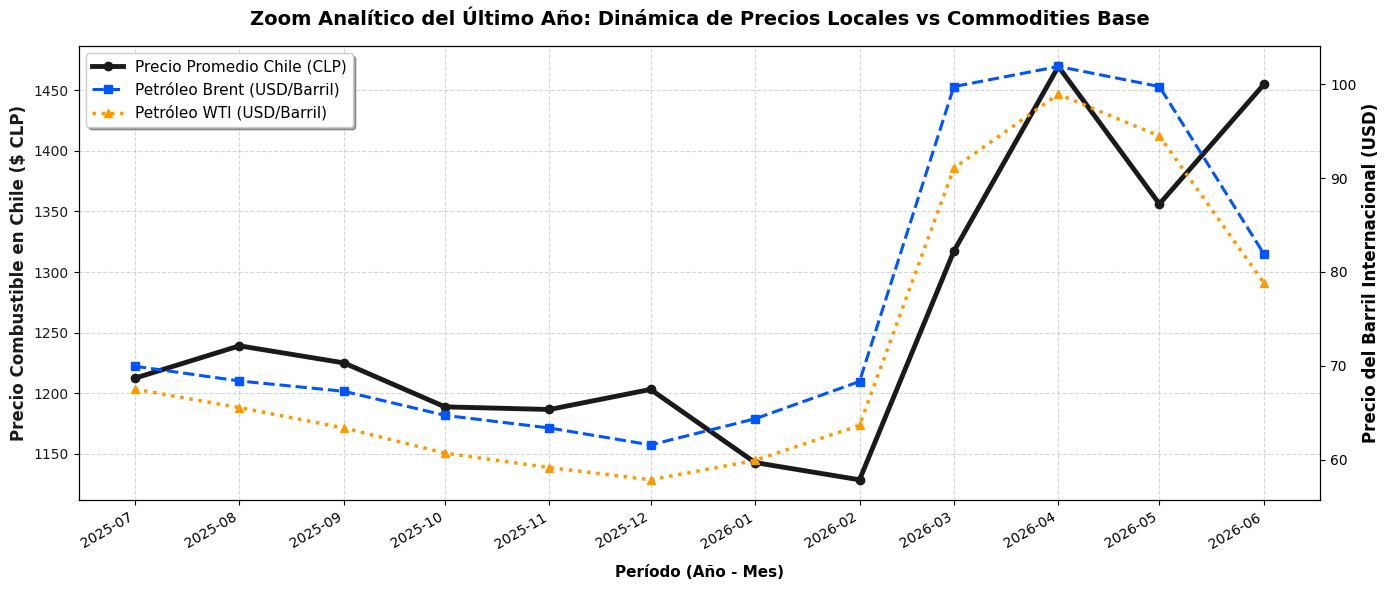

In [16]:
# 1. Asegurar el formato de fecha en el dataset limpio
df_limpio['fecha_actualizacion'] = pd.to_datetime(df_limpio['fecha_actualizacion'])

# 2. Agrupar por MES y calcular promedios (usando las columnas originales)
df_mensual = df_limpio.set_index('fecha_actualizacion').resample('MS').agg({
    'precio': 'mean',
    'Precio_Brent_USD': 'mean',
    'Precio_WTI_USD': 'mean'
}).sort_index()

# FILTRO CLAVE: Extraemos únicamente los últimos 12 meses disponibles de la serie histórica
df_ultimo_ano = df_mensual.tail(12)

# 3. Configuración del lienzo
fig, ax1 = plt.subplots(figsize=(14, 6))

# Paleta estricta de colores de alto contraste
color_chile = '#1A1A1A'  # Negro Carbón
color_brent = '#0055FF'  # Azul Eléctrico
color_wti = '#FF9900'    # Naranja Neón / Ámbar

# --- EJE IZQUIERDO: Mercado Chileno ($ CLP) ---
ax1.plot(df_ultimo_ano.index, df_ultimo_ano['precio'],
         color=color_chile, linestyle='-', linewidth=3.5, marker='o', label='Precio Promedio Chile (CLP)')

# Se corrige 'pad=10' por 'labelpad=10'
ax1.set_xlabel('Período (Año - Mes)', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Precio Combustible en Chile ($ CLP)', color=color_chile, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_chile)
ax1.grid(True, linestyle='--', alpha=0.5)

# Formatear el eje X para mostrar claramente cada mes del último año
ax1.set_xticks(df_ultimo_ano.index)
ax1.set_xticklabels([d.strftime('%Y-%m') for d in df_ultimo_ano.index], rotation=30, ha='right')

# --- EJE DERECHO: Mercado Internacional ($ USD por Barril) ---
ax2 = ax1.twinx()

# Brent: Línea segmentada con marcadores
ax2.plot(df_ultimo_ano.index, df_ultimo_ano['Precio_Brent_USD'],
         color=color_brent, linestyle='--', linewidth=2.2, marker='s', label='Petróleo Brent (USD/Barril)')

# WTI: Línea de puntos con marcadores
ax2.plot(df_ultimo_ano.index, df_ultimo_ano['Precio_WTI_USD'],
         color=color_wti, linestyle=':', linewidth=2.5, marker='^', label='Petróleo WTI (USD/Barril)')

ax2.set_ylabel('Precio del Barril Internacional (USD)', color='black', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='black')
ax2.grid(False) # Evitamos duplicar líneas de cuadrícula para no saturar el gráfico

# 4. Unificar y posicionar leyendas con sombra formal
lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()
ax1.legend(lineas_1 + lineas_2, etiquetas_1 + etiquetas_2,
           loc='upper left', fontsize=11, facecolor='white', frameon=True, shadow=True)

plt.title('Zoom Analítico del Último Año: Dinámica de Precios Locales vs Commodities Base', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 5.5. Conclusiones Clave del Gráfico

1. **Traspaso Lento (Desfase):** Las alzas y bajas drásticas del petróleo internacional (Brent y WTI) no afectan de inmediato al bolsillo chileno. Existe un retraso de varias semanas antes de que los cambios externos se reflejen en las estaciones de servicio.

2. **Efecto MEPCO (Amortiguación):** Mientras las líneas azul y naranja del crudo son muy inestables y volátiles, la línea negra de Chile es suave y controlada. Esto demuestra con datos reales que el subsidio estatal (MEPCO) cumple con éxito su objetivo de frenar los impactos económicos agresivos.

3. **Validación del Modelo:** La Regresión Lineal asume que si el petróleo sube, el precio local sube de inmediato en la misma proporción (lo cual no pasa por el subsidio). Esto justifica por qué un **Árbol de Decisión** es una mejor opción metodológica, ya que sus reglas lógicas se adaptan mejor a los topes y bandas de precio fijadas por el gobierno.

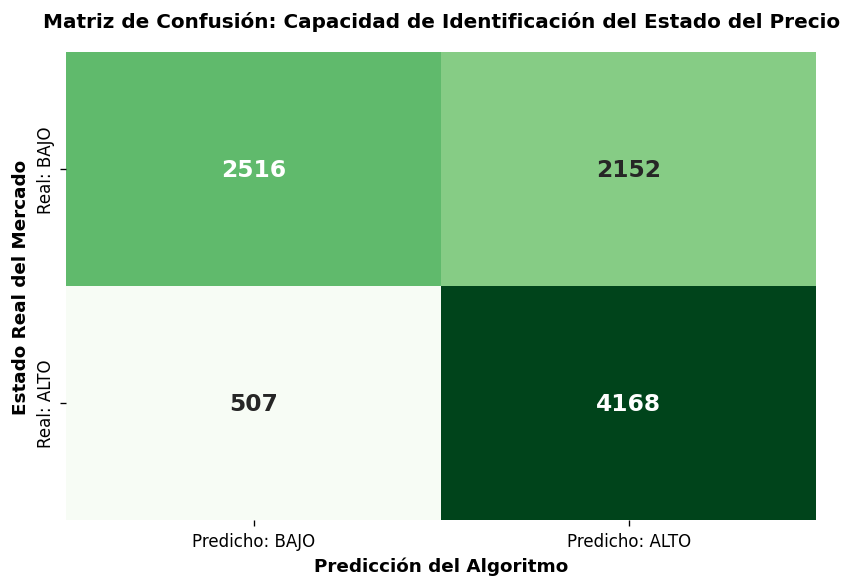

=== REPORTE DE CLASIFICACIÓN ASOCIADO ===
              precision    recall  f1-score   support

 Precio Bajo       0.83      0.54      0.65      4668
 Precio Alto       0.66      0.89      0.76      4675

    accuracy                           0.72      9343
   macro avg       0.75      0.72      0.71      9343
weighted avg       0.75      0.72      0.71      9343



In [17]:
df_macro = df_limpio.groupby(['fecha_actualizacion', 'combustible']).agg({
    'precio': 'mean',
    'Precio_Brent_USD': 'mean',
    'Precio_WTI_USD': 'mean'
}).reset_index()

df_modelacion = pd.get_dummies(df_macro, columns=['combustible'], drop_first=True)
columnas_combustible = [col for col in df_modelacion.columns if 'combustible_' in col]

X = df_modelacion[['Precio_Brent_USD', 'Precio_WTI_USD'] + columnas_combustible]
y = df_modelacion['precio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
# ----------------------------------------------------------------------------------------

# 1. Definir el umbral económico (La mediana de los precios reales de prueba)
umbral_mediana = y_test.median()

# 2. Transformar los precios continuos en categorías: 0 para 'Precio Bajo', 1 para 'Precio Alto'
y_test_binario = np.where(y_test >= umbral_mediana, 1, 0)
y_pred_binario = np.where(y_pred_lr >= umbral_mediana, 1, 0)

# 3. Calcular la matriz de confusión estricta
cm = confusion_matrix(y_test_binario, y_pred_binario)

# 4. Configurar la visualización del mapa de calor
plt.figure(figsize=(7, 5), dpi=120)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicho: BAJO', 'Predicho: ALTO'],
    yticklabels=['Real: BAJO', 'Real: ALTO'],
    annot_kws={"size": 14, "weight": "bold"},
    cbar=False
)

# 5. Estética formal
plt.title('Matriz de Confusión: Capacidad de Identificación del Estado del Precio', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Estado Real del Mercado', fontsize=11, fontweight='bold')
plt.xlabel('Predicción del Algoritmo', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Mostrar el reporte de métricas de clasificación en texto
print("=== REPORTE DE CLASIFICACIÓN ASOCIADO ===")
print(classification_report(y_test_binario, y_pred_binario, target_names=['Precio Bajo', 'Precio Alto']))

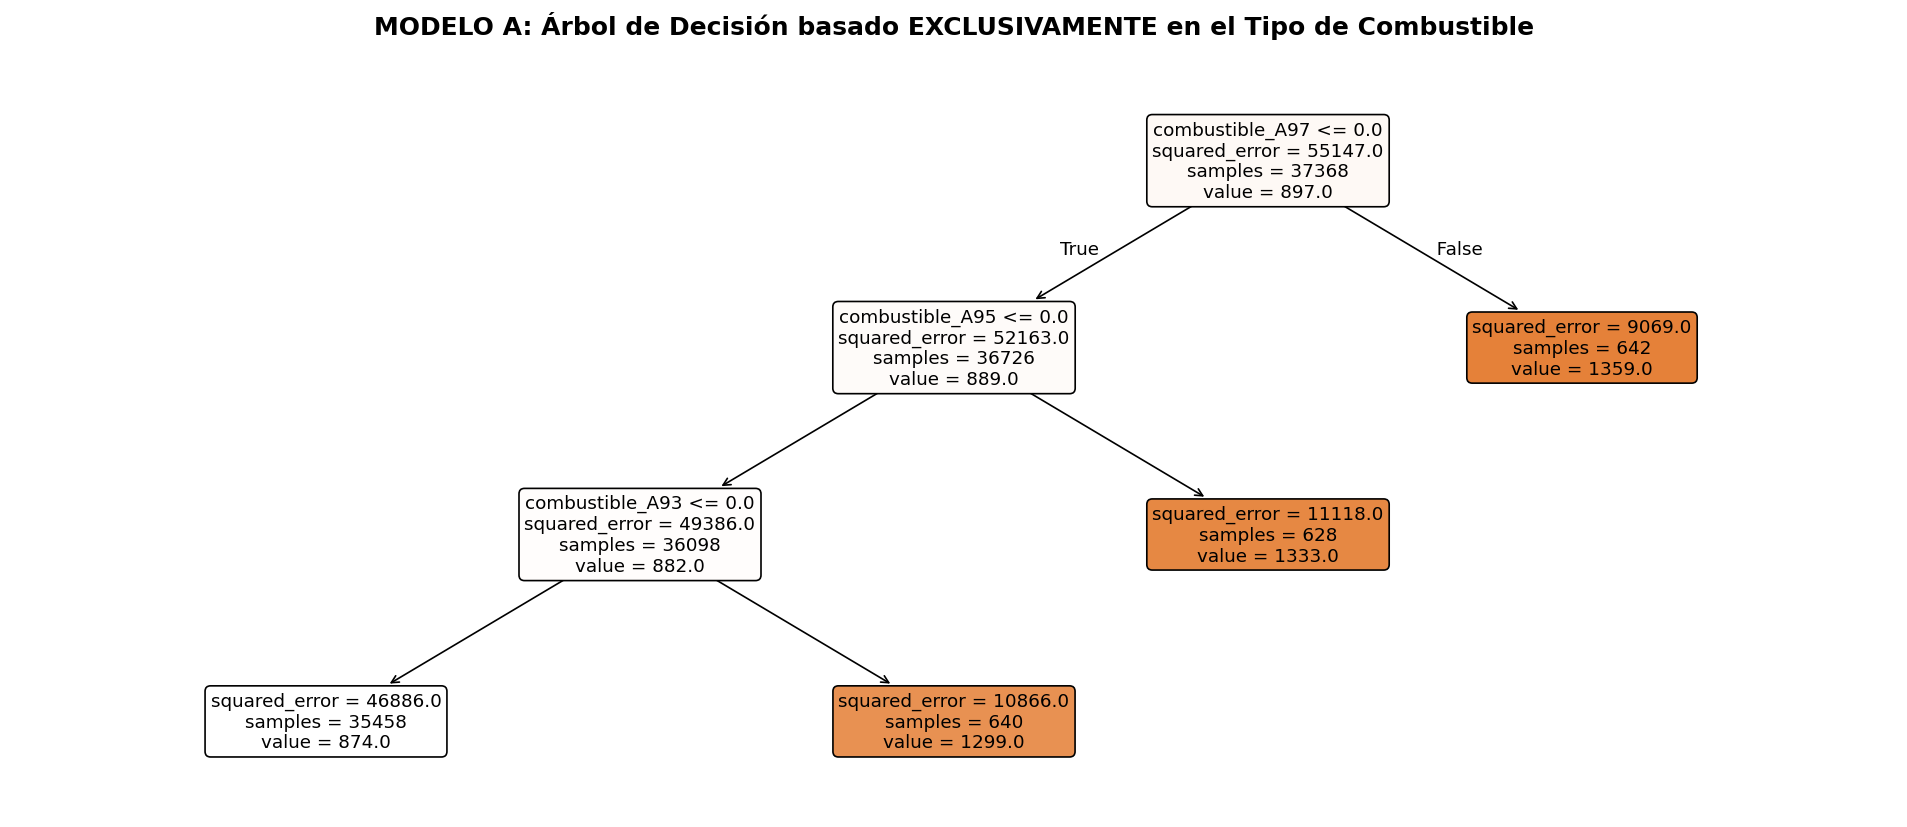

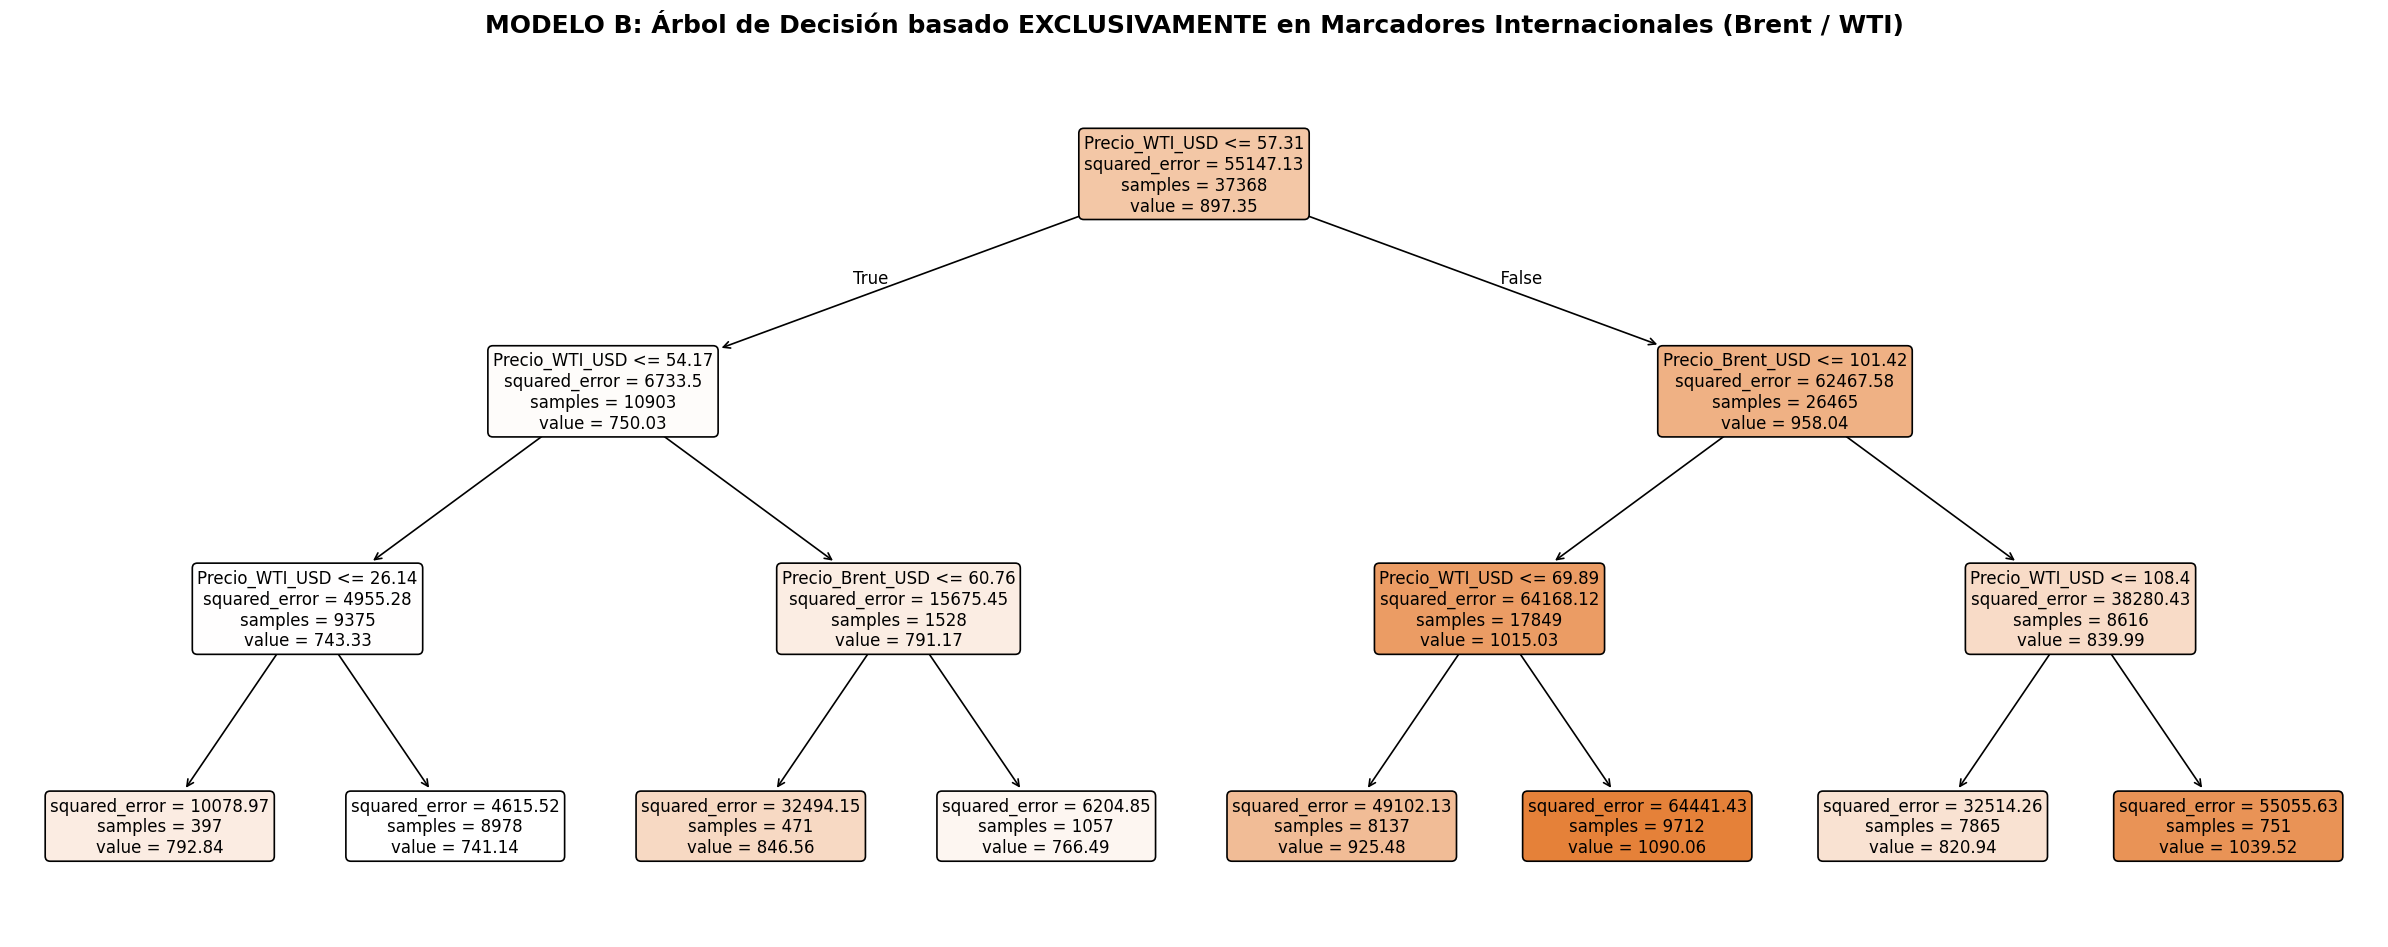

In [18]:
# --- PREPARACIÓN DE DATOS AISLADOS ---
# 1. Variables de Combustible (Solo las Dummies locales)
X_combustible = df_modelacion[columnas_combustible]
# 2. Variables de Petróleo (Solo los commodities internacionales)
X_petroleo = df_modelacion[['Precio_Brent_USD', 'Precio_WTI_USD']]
# Target (Precio en Chile)
y_aislado = df_modelacion['precio']

# Splits Independientes
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_combustible, y_aislado, test_size=0.20, random_state=42)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_petroleo, y_aislado, test_size=0.20, random_state=42)

# --- ENTRENAMIENTO ---
# Árbol 1: Solo Combustible (Profundidad 3 es suficiente para separar 4 combustibles)
dt_combustible = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_combustible.fit(X_train_c, y_train_c)

# Árbol 2: Solo Petróleo (Profundidad 3 para ver los cortes principales)
dt_petroleo = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_petroleo.fit(X_train_p, y_train_p)

# ====================================================================
# VISUALIZACIÓN 1: ÁRBOL DE COMBUSTIBLES
# ====================================================================
plt.figure(figsize=(16, 7), dpi=120)
plot_tree(dt_combustible, feature_names=X_train_c.columns.tolist(), filled=True, rounded=True, fontsize=11, precision=0)
plt.title('MODELO A: Árbol de Decisión basado EXCLUSIVAMENTE en el Tipo de Combustible', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ====================================================================
# VISUALIZACIÓN 2: ÁRBOL DE PETRÓLEO INTERNACIONAL
# ====================================================================
plt.figure(figsize=(20, 8), dpi=120)
plot_tree(dt_petroleo, feature_names=X_train_p.columns.tolist(), filled=True, rounded=True, fontsize=10, precision=2)
plt.title('MODELO B: Árbol de Decisión basado EXCLUSIVAMENTE en Marcadores Internacionales (Brent / WTI)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

=== MÉTRICAS DE REGRESIÓN LINEAL (PROMEDIO NACIONAL) ===
Coeficiente de Determinación (R²): 0.2969
Error Absoluto Medio (MAE):        $167.02 CLP
Raíz del Error Cuadrático (RMSE):  $200.97 CLP



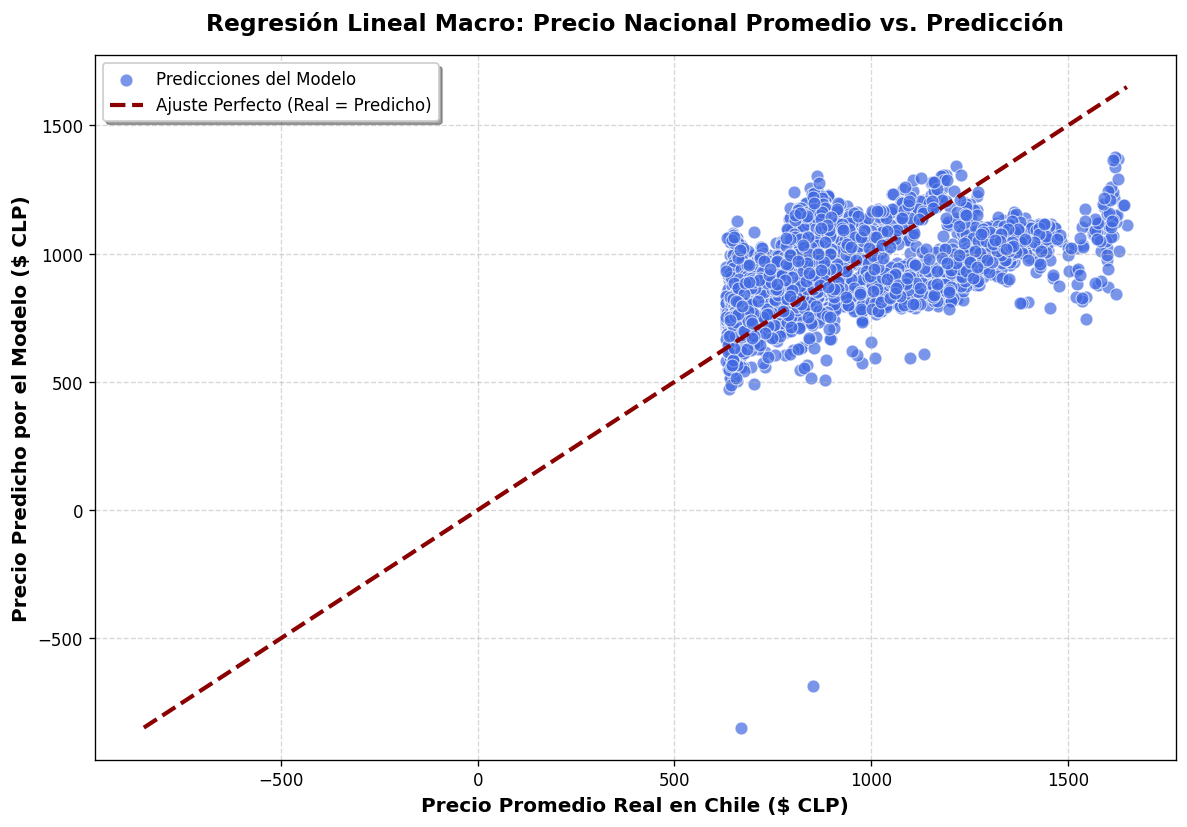

In [22]:
# 1. AGRUPACIÓN MACRO: Calculamos el precio promedio nacional por día y tipo de combustible
# Esto elimina el "ruido" de las diferencias de precio entre gasolineras individuales
df_macro = df_limpio.groupby(['fecha_actualizacion', 'combustible']).agg({
    'precio': 'mean',
    'Precio_Brent_USD': 'mean',
    'Precio_WTI_USD': 'mean'
}).reset_index()

# 2. Preparación de variables categóricas (One-Hot Encoding)
df_modelacion = pd.get_dummies(df_macro, columns=['combustible'], drop_first=True)
columnas_combustible = [col for col in df_modelacion.columns if 'combustible_' in col]

# 3. Definición de Variables (X e y)
X = df_modelacion[['Precio_Brent_USD', 'Precio_WTI_USD'] + columnas_combustible]
y = df_modelacion['precio']

# 4. División de datos (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

# 5. Configurar y entrenar el modelo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 6. Calcular e Imprimir Métricas
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("=== MÉTRICAS DE REGRESIÓN LINEAL (PROMEDIO NACIONAL) ===")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Absoluto Medio (MAE):        ${mae:.2f} CLP")
print(f"Raíz del Error Cuadrático (RMSE):  ${rmse:.2f} CLP\n")

# 7. Visualización
plt.figure(figsize=(10, 7), dpi=120)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.7, color='royalblue', edgecolor='w', s=60, label='Predicciones del Modelo')

# Línea de Ajuste Perfecto
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, color='darkred', linestyle='--', linewidth=2.5, label='Ajuste Perfecto (Real = Predicho)')

plt.title('Regresión Lineal Macro: Precio Nacional Promedio vs. Predicción', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio Promedio Real en Chile ($ CLP)', fontsize=12, fontweight='bold')
plt.ylabel('Precio Predicho por el Modelo ($ CLP)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ===============================================
# PREPROCESAMIENTO: HOMOLOGACIÓN DE CATEGORÍAS DE COMBUSTIBLE
# ==================================================

In [20]:
# 1. Verificamos cuántas categorías distintas hay antes de limpiar (Opcional, para comparar)
print("Categorías originales:", df_limpio['combustible'].unique())

# 2. Creamos un diccionario para unificar todos los nombres bajo un estándar claro
diccionario_combustibles = {
    # Gasolina 93
    '93': 'Gasolina 93', 'A93': 'Gasolina 93', 'a93': 'Gasolina 93', 'Gasolina 93': 'Gasolina 93',

    # Gasolina 95
    '95': 'Gasolina 95', 'A95': 'Gasolina 95', 'a95': 'Gasolina 95', 'Gasolina 95': 'Gasolina 95',

    # Gasolina 97
    '97': 'Gasolina 97', 'A97': 'Gasolina 97', 'a97': 'Gasolina 97', 'Gasolina 97': 'Gasolina 97',

    # Diesel
    'Petroleo Diesel': 'Diesel', 'DI': 'Diesel', 'ADI': 'Diesel', 'diesel': 'Diesel',

    # Kerosene (Parafina)
    'Kerosene': 'Kerosene', 'KE': 'Kerosene', 'AKE': 'Kerosene',

    # Gases
    'GLP Vehicular': 'GLP', 'GLP': 'GLP',
    'GNC': 'GNC',

    # Otros
    'Electricidad': 'Electricidad'
}

# 3. Aplicamos la corrección a toda la columna
df_limpio['combustible'] = df_limpio['combustible'].replace(diccionario_combustibles)

# 4. Verificamos que la limpieza haya sido un éxito
print("\nCategorías limpias:", df_limpio['combustible'].unique())

Categorías originales: ['Gasolina 95' '93' '95' '97' 'Gasolina 93' 'Gasolina 97' 'Kerosene'
 'Petroleo Diesel' 'DI' 'KE' 'GLP Vehicular' 'GNC' 'GLP' 'Electricidad'
 'A97' 'A95' 'ADI' 'A93' 'AKE']

Categorías limpias: ['Gasolina 95' 'Gasolina 93' 'Gasolina 97' 'Kerosene' 'Diesel' 'GLP' 'GNC'
 'Electricidad']


/tmp/ipykernel_1067/1476823886.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


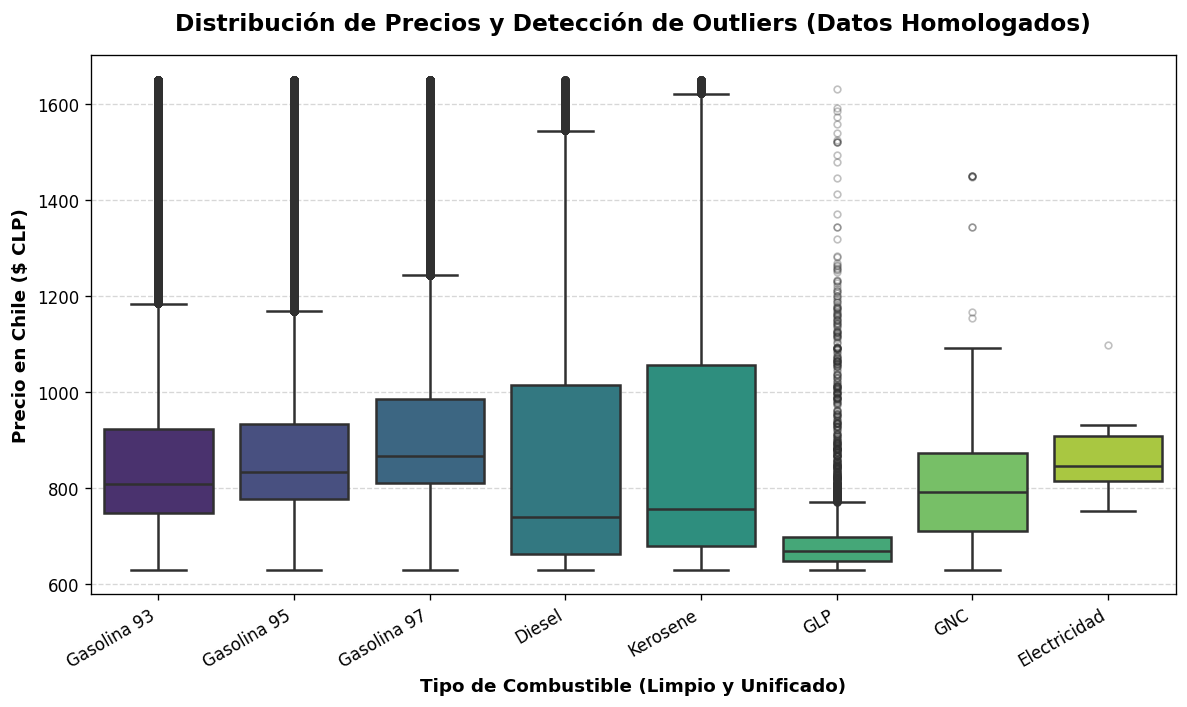

In [24]:
# 1. Configurar el lienzo (ahora puede ser un poco más compacto porque hay menos ruido)
plt.figure(figsize=(10, 6), dpi=120)

# 2. Definimos un orden lógico para las categorías principales en el eje X
# Esto hará que tu gráfico se lea de forma impecable de izquierda a derecha
orden_combustibles = ['Gasolina 93', 'Gasolina 95', 'Gasolina 97', 'Diesel', 'Kerosene', 'GLP', 'GNC', 'Electricidad']

# Filtramos la lista para usar solo las categorías que realmente existan en tu dataset limpio
orden_existente = [c for c in orden_combustibles if c in df_limpio['combustible'].unique()]

# 3. Crear el Boxplot
sns.boxplot(
    data=df_limpio,
    x='combustible',
    y='precio',
    order=orden_existente,
    palette='viridis',
    linewidth=1.5,
    flierprops=dict(marker='o', color='red', markersize=4, alpha=0.3) # Outliers en rojo sutil
)

# 4. Estética y etiquetas
plt.title('Distribución de Precios y Detección de Outliers (Datos Homologados)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Combustible (Limpio y Unificado)', fontsize=11, fontweight='bold')
plt.ylabel('Precio en Chile ($ CLP)', fontsize=11, fontweight='bold')

# Al tener menos categorías, no necesitamos rotar tanto el texto (30 grados es suficiente)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Cuadrícula de fondo sutil
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [29]:
# Definimos el periodo de análisis (puedes ajustar las fechas)
FECHA_INICIO = '2012-01-01'
FECHA_FIN = '2026-07-14'

print("Descargando datos financieros...")

# 1. Descargar el precio histórico del Dólar (USDCLP=X)
dolar = yf.download('USDCLP=X', start=FECHA_INICIO, end=FECHA_FIN, progress=False)
df_dolar = dolar[['Close']].reset_index()
df_dolar.columns = ['fecha', 'dolar_clp']

# 2. Descargar el precio histórico del Petróleo Brent (BZ=F)
brent = yf.download('BZ=F', start=FECHA_INICIO, end=FECHA_FIN, progress=False)
df_brent = brent[['Close']].reset_index()
df_brent.columns = ['fecha', 'precio_brent_usd']

# 3. Descargar el precio histórico del Petróleo WTI (CL=F) -> ¡AQUÍ LO AGREGAMOS!
wti = yf.download('CL=F', start=FECHA_INICIO, end=FECHA_FIN, progress=False)
df_wti = wti[['Close']].reset_index()
df_wti.columns = ['fecha', 'precio_wti_usd']

# 4. Limpieza de fechas
df_dolar['fecha'] = pd.to_datetime(df_dolar['fecha']).dt.tz_localize(None)
df_brent['fecha'] = pd.to_datetime(df_brent['fecha']).dt.tz_localize(None)
df_wti['fecha'] = pd.to_datetime(df_wti['fecha']).dt.tz_localize(None)

# Ordenamos obligatoriamente antes de hacer los cruces
df_dolar = df_dolar.sort_values('fecha')
df_brent = df_brent.sort_values('fecha')
df_wti = df_wti.sort_values('fecha')

# 5. Cruzar los datos (Usamos merge_asof en cadena)
# Primero unimos los dos petróleos
df_petroleos = pd.merge_asof(df_brent, df_wti, on='fecha', direction='nearest')

# Luego unimos los petróleos con el tipo de cambio (Dólar)
df_analisis = pd.merge_asof(df_petroleos, df_dolar, on='fecha', direction='backward')

# 6. Transformación matemática a Costo Base Local
LITROS_POR_BARRIL = 158.987

# Fórmula Brent: (Precio USD / 158.987) * Dolar_Historico
df_analisis['brent_clp_litro'] = (df_analisis['precio_brent_usd'] / LITROS_POR_BARRIL) * df_analisis['dolar_clp']

# Fórmula WTI: (Precio USD / 158.987) * Dolar_Historico
df_analisis['wti_clp_litro'] = (df_analisis['precio_wti_usd'] / LITROS_POR_BARRIL) * df_analisis['dolar_clp']

# Limpiamos valores nulos (días sin cotización en algún mercado)
df_analisis = df_analisis.dropna()

print("\nDataset finalizado con Brent y WTI (Últimos 5 registros):")
print(df_analisis.tail())

Descargando datos financieros...


/tmp/ipykernel_1067/2523892961.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dolar = yf.download('USDCLP=X', start=FECHA_INICIO, end=FECHA_FIN, progress=False)
/tmp/ipykernel_1067/2523892961.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  brent = yf.download('BZ=F', start=FECHA_INICIO, end=FECHA_FIN, progress=False)
/tmp/ipykernel_1067/2523892961.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  wti = yf.download('CL=F', start=FECHA_INICIO, end=FECHA_FIN, progress=False)



Dataset finalizado con Brent y WTI (Últimos 5 registros):
          fecha  precio_brent_usd  precio_wti_usd  dolar_clp  brent_clp_litro  \
3629 2026-07-07             74.16           70.44     927.58           432.67   
3630 2026-07-08             78.02           73.52     926.49           454.66   
3631 2026-07-09             76.30           72.08     934.66           448.56   
3632 2026-07-10             76.01           71.41     926.96           443.17   
3633 2026-07-13             83.30           78.14     926.87           485.63   

      wti_clp_litro  
3629         410.97  
3630         428.43  
3631         423.75  
3632         416.35  
3633         455.54  


In [31]:
# Convertimos la fecha de tu df_macro a datetime para asegurar que coincidan
df_macro['fecha_actualizacion'] = pd.to_datetime(df_macro['fecha_actualizacion'])

# Cruzamos tu tabla agrupada (macro) con los datos financieros que acabas de descargar
df_final = pd.merge(df_macro, df_analisis, left_on='fecha_actualizacion', right_on='fecha', how='inner')

In [33]:
# Eliminar las columnas duplicadas que generó el cruce
df_final = df_final.drop(columns=['fecha', 'precio_brent_usd', 'precio_wti_usd'])

# Verificar cómo quedó
df_final.head()

,fecha_actualizacion,combustible,precio,Precio_Brent_USD,Precio_WTI_USD,dolar_clp,brent_clp_litro,wti_clp_litro
0,2012-01-03,Gasolina 93,752.21,112.13,102.96,517.00,364.63,334.81
1,2012-01-03,Gasolina 95,768.89,112.13,102.96,517.00,364.63,334.81
2,2012-01-03,Gasolina 97,794.15,112.13,102.96,517.00,364.63,334.81
3,2012-01-03,Kerosene,644.00,112.13,102.96,517.00,364.63,334.81
4,2012-01-04,Gasolina 93,745.00,113.70,103.22,511.25,365.62,331.92


In [34]:
df_final.tail()

,fecha_actualizacion,combustible,precio,Precio_Brent_USD,Precio_WTI_USD,dolar_clp,brent_clp_litro,wti_clp_litro
18025,2026-06-18,Kerosene,1083.30,79.85,76.60,886.35,445.16,427.04
18026,2026-06-22,Diesel,1332.00,77.90,74.82,901.21,441.57,424.11
18027,2026-06-22,Gasolina 93,1501.22,77.90,74.82,901.21,441.57,424.11
18028,2026-06-22,Gasolina 95,1527.00,77.90,74.82,901.21,441.57,424.11
18029,2026-06-22,Kerosene,1035.00,77.90,74.82,901.21,441.57,424.11
